**Importing Necessary Libraries**

In [1062]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.combine import SMOTETomek

import pickle

**Load Dataset**

In [982]:
df = pd.read_csv("gym_members_dataset.csv")

In [983]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Member_ID                 150 non-null    int64  
 1   Name                      127 non-null    object 
 2   Age                       137 non-null    float64
 3   Gender                    150 non-null    object 
 4   Address                   150 non-null    object 
 5   Phone_Number              150 non-null    object 
 6   Membership_Type           150 non-null    object 
 7   Join_Date                 141 non-null    object 
 8   Last_Visit_Date           150 non-null    object 
 9   Favorite_Exercise         150 non-null    object 
 10  Avg_Workout_Duration_Min  150 non-null    int64  
 11  Avg_Calories_Burned       139 non-null    float64
 12  Total_Weight_Lifted_kg    142 non-null    float64
 13  Visits_Per_Month          138 non-null    float64
 14  Churn     

In [984]:
df.head()

,Member_ID,Name,Age,Gender,Address,Phone_Number,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
0,1,NaN,19.0,Male,"Street 171, City 39",032-51510359,Quarterly,2022-07-23,2022-11-03,Pull-ups,93,214.0,13995.0,18.0,No
1,2,Shanza,19.0,Female,"Street 111, City 18",039-19243328,Monthly,2023-12-04,2024-02-14,Squats,37,436.0,4612.0,11.0,No
2,3,Ubaidullah,52.0,Male,"Street 69, City 21",033-60221501,Quarterly,2024-09-13,2024-12-07,Bench Press,98,523.0,3124.0,4.0,Yes
3,4,Mansoor Ahmed,52.0,Male,"Street 72, City 39",035-55527902,Monthly,2024-06-05,2025-02-24,Pull-ups,66,282.0,4586.0,24.0,No
4,5,Hanzala,32.0,Male,"Street 6, City 12",038-93946322,Monthly,2022-06-15,2022-12-02,Bench Press,32,522.0,16353.0,18.0,No


In [985]:
df.shape

(150, 15)

In [986]:
df.describe()

,Member_ID,Age,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month
count,150.000000,137.000000,150.000000,139.000000,142.000000,138.000000
mean,75.500000,35.905109,73.326667,488.309353,9486.978873,14.224638
std,43.445368,11.654892,25.879560,168.649317,5127.955128,6.385451
min,1.000000,18.000000,30.000000,209.000000,1009.000000,4.000000
25%,38.250000,25.000000,53.000000,341.500000,5274.000000,8.000000
50%,75.500000,36.000000,74.000000,496.000000,9072.500000,14.000000
75%,112.750000,46.000000,94.500000,627.500000,13620.750000,20.000000
max,150.000000,54.000000,119.000000,788.000000,19722.000000,24.000000


In [987]:
df.isnull().sum()

Member_ID                    0
Name                        23
Age                         13
Gender                       0
Address                      0
Phone_Number                 0
Membership_Type              0
Join_Date                    9
Last_Visit_Date              0
Favorite_Exercise            0
Avg_Workout_Duration_Min     0
Avg_Calories_Burned         11
Total_Weight_Lifted_kg       8
Visits_Per_Month            12
Churn                        0
dtype: int64

**Remove Irrelevant Columns**

In [988]:
df.drop(columns = ["Member_ID","Name","Address","Phone_Number"],
       inplace = True,
       axis = 1)

In [989]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       137 non-null    float64
 1   Gender                    150 non-null    object 
 2   Membership_Type           150 non-null    object 
 3   Join_Date                 141 non-null    object 
 4   Last_Visit_Date           150 non-null    object 
 5   Favorite_Exercise         150 non-null    object 
 6   Avg_Workout_Duration_Min  150 non-null    int64  
 7   Avg_Calories_Burned       139 non-null    float64
 8   Total_Weight_Lifted_kg    142 non-null    float64
 9   Visits_Per_Month          138 non-null    float64
 10  Churn                     150 non-null    object 
dtypes: float64(4), int64(1), object(6)
memory usage: 13.0+ KB


**Handling missing values**

In [990]:
df["Age"] = round(df["Age"].fillna(df["Age"].mean()))
df["Avg_Calories_Burned"] = round(df["Avg_Calories_Burned"].fillna(df["Avg_Calories_Burned"].mean()))
df["Total_Weight_Lifted_kg"] = round(df["Total_Weight_Lifted_kg"].fillna(df["Total_Weight_Lifted_kg"].mean()))
df["Visits_Per_Month"] = round(df["Visits_Per_Month"].fillna(df["Visits_Per_Month"].mean()))


In [991]:
df["Join_Date"] = pd.to_datetime(df["Join_Date"])
df["Last_Visit_Date"] = pd.to_datetime(df["Last_Visit_Date"])

In [992]:
JD_null = df[df["Join_Date"].isnull()]

In [993]:
JD_null

,Age,Gender,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
57,53.0,Female,Quarterly,NaT,2025-02-22,Pull-ups,59,342.0,3849.0,7.0,Yes
86,36.0,Male,Monthly,NaT,2023-02-20,Squats,72,488.0,8466.0,20.0,No
90,37.0,Female,Monthly,NaT,2023-08-07,Pull-ups,114,268.0,9945.0,6.0,Yes
95,50.0,Female,Yearly,NaT,2023-08-08,Squats,119,503.0,9487.0,14.0,No
97,29.0,Female,Yearly,NaT,2022-05-17,Treadmill,82,580.0,9391.0,11.0,No
101,46.0,Male,Yearly,NaT,2024-10-08,Pull-ups,30,617.0,2805.0,7.0,Yes
118,50.0,Female,Monthly,NaT,2024-04-18,Bench Press,59,465.0,4464.0,11.0,No
123,52.0,Female,Monthly,NaT,2022-09-23,Pull-ups,41,249.0,13617.0,21.0,No
130,33.0,Male,Monthly,NaT,2024-08-24,Deadlift,65,769.0,10715.0,6.0,Yes


In [994]:
def clean_join_date(row, mode_date):
    
    # Fill null Join_Date with mode
    if pd.isnull(row["Join_Date"]):
        row["Join_Date"] = mode_date
    
    # If Join_Date > Last_Visited, return null
    if row["Join_Date"] > row["Last_Visit_Date"]:
        return np.nan
    
    return row["Join_Date"]

In [995]:
mode_date = df["Join_Date"].mode()[0]

In [996]:
df["Join_Date"] = df.apply(
    lambda row: clean_join_date(row, mode_date),
    axis=1
)

In [997]:
df.loc[JD_null.index]

,Age,Gender,Membership_Type,Join_Date,Last_Visit_Date,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn
57,53.0,Female,Quarterly,2022-10-10,2025-02-22,Pull-ups,59,342.0,3849.0,7.0,Yes
86,36.0,Male,Monthly,2022-10-10,2023-02-20,Squats,72,488.0,8466.0,20.0,No
90,37.0,Female,Monthly,2022-10-10,2023-08-07,Pull-ups,114,268.0,9945.0,6.0,Yes
95,50.0,Female,Yearly,2022-10-10,2023-08-08,Squats,119,503.0,9487.0,14.0,No
97,29.0,Female,Yearly,NaT,2022-05-17,Treadmill,82,580.0,9391.0,11.0,No
101,46.0,Male,Yearly,2022-10-10,2024-10-08,Pull-ups,30,617.0,2805.0,7.0,Yes
118,50.0,Female,Monthly,2022-10-10,2024-04-18,Bench Press,59,465.0,4464.0,11.0,No
123,52.0,Female,Monthly,NaT,2022-09-23,Pull-ups,41,249.0,13617.0,21.0,No
130,33.0,Male,Monthly,2022-10-10,2024-08-24,Deadlift,65,769.0,10715.0,6.0,Yes


In [998]:
df.isnull().sum()

Age                         0
Gender                      0
Membership_Type             0
Join_Date                   2
Last_Visit_Date             0
Favorite_Exercise           0
Avg_Workout_Duration_Min    0
Avg_Calories_Burned         0
Total_Weight_Lifted_kg      0
Visits_Per_Month            0
Churn                       0
dtype: int64

In [999]:
df = df.dropna(subset = ["Join_Date"])

In [1000]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Age                       148 non-null    float64       
 1   Gender                    148 non-null    object        
 2   Membership_Type           148 non-null    object        
 3   Join_Date                 148 non-null    datetime64[ns]
 4   Last_Visit_Date           148 non-null    datetime64[ns]
 5   Favorite_Exercise         148 non-null    object        
 6   Avg_Workout_Duration_Min  148 non-null    int64         
 7   Avg_Calories_Burned       148 non-null    float64       
 8   Total_Weight_Lifted_kg    148 non-null    float64       
 9   Visits_Per_Month          148 non-null    float64       
 10  Churn                     148 non-null    object        
dtypes: datetime64[ns](2), float64(4), int64(1), object(4)
memory usage: 13.9+ KB


**Feature Engineering**

In [1001]:
# Duration between joining and last visit

df['Membership_Duration_Days'] = (
    df['Last_Visit_Date'] - df['Join_Date']
).dt.days

In [1002]:
# Workout efficiency

df['Calories_per_Min'] = (
    df['Avg_Calories_Burned'] /
    df['Avg_Workout_Duration_Min']
)

In [1003]:
df['Joining_Month'] = df['Join_Date'].dt.month

In [1004]:
# Convert month to season

def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Summer'
    elif month in [6, 7, 8, 9]:
        return 'Monsoon'
    else:
        return 'Autumn'


df['Joining_Season'] = df['Joining_Month'].apply(get_season)

In [1005]:
# Create age categories

def classify_age(age):
    if age <= 19:
        return 'Teenagers'
    elif age <= 29:
        return 'Young Adults'
    elif age <= 45:
        return 'Adults'
    elif age <= 60:
        return 'Middle Age'
    else:
        return 'Senior Citizens'


df['Age_Group'] = df['Age'].apply(classify_age)

In [1006]:
# Engagement based on workout duration and monthly gym visits

df['Workout_Engagement_Score'] = (
    df['Avg_Workout_Duration_Min'] *
    df['Visits_Per_Month']
)

In [1007]:
## Average Calories Per Visit

df['Calories_Per_Visit'] = (
    df['Avg_Calories_Burned'] /
    (df['Visits_Per_Month'] + 1)
)

In [1008]:
# Remove original date columns

df.drop(columns=['Join_Date', 'Last_Visit_Date'], inplace=True)

In [1009]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 149
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Age                       148 non-null    float64
 1   Gender                    148 non-null    object 
 2   Membership_Type           148 non-null    object 
 3   Favorite_Exercise         148 non-null    object 
 4   Avg_Workout_Duration_Min  148 non-null    int64  
 5   Avg_Calories_Burned       148 non-null    float64
 6   Total_Weight_Lifted_kg    148 non-null    float64
 7   Visits_Per_Month          148 non-null    float64
 8   Churn                     148 non-null    object 
 9   Membership_Duration_Days  148 non-null    int64  
 10  Calories_per_Min          148 non-null    float64
 11  Joining_Month             148 non-null    int32  
 12  Joining_Season            148 non-null    object 
 13  Age_Group                 148 non-null    object 
 14  Workout_Engagem

In [1010]:
df.head()

,Age,Gender,Membership_Type,Favorite_Exercise,Avg_Workout_Duration_Min,Avg_Calories_Burned,Total_Weight_Lifted_kg,Visits_Per_Month,Churn,Membership_Duration_Days,Calories_per_Min,Joining_Month,Joining_Season,Age_Group,Workout_Engagement_Score,Calories_Per_Visit
0,19.0,Male,Quarterly,Pull-ups,93,214.0,13995.0,18.0,No,103,2.301075,7,Monsoon,Teenagers,1674.0,11.263158
1,19.0,Female,Monthly,Squats,37,436.0,4612.0,11.0,No,72,11.783784,12,Winter,Teenagers,407.0,36.333333
2,52.0,Male,Quarterly,Bench Press,98,523.0,3124.0,4.0,Yes,85,5.336735,9,Monsoon,Middle Age,392.0,104.600000
3,52.0,Male,Monthly,Pull-ups,66,282.0,4586.0,24.0,No,264,4.272727,6,Monsoon,Middle Age,1584.0,11.280000
4,32.0,Male,Monthly,Bench Press,32,522.0,16353.0,18.0,No,170,16.312500,6,Monsoon,Adults,576.0,27.473684


**Exploratory Data Analysis**

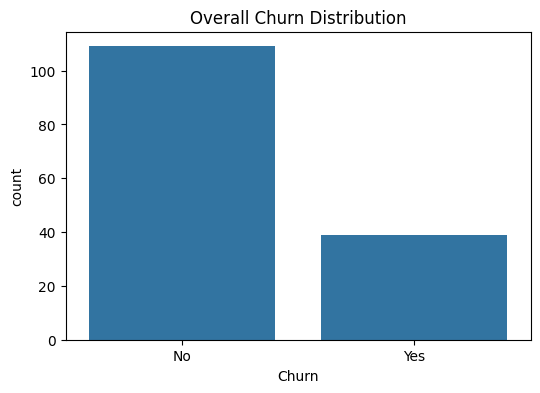

In [1011]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Churn',
    data=df
)

plt.title('Overall Churn Distribution')
plt.show()

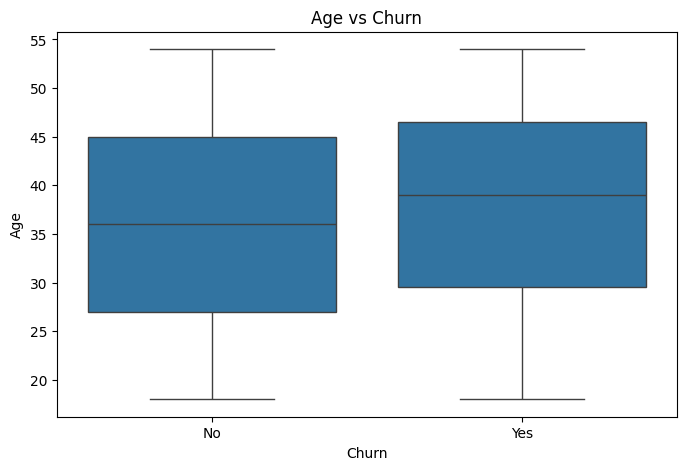

In [1012]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Age',
    data=df
)

plt.title('Age vs Churn')
plt.show()

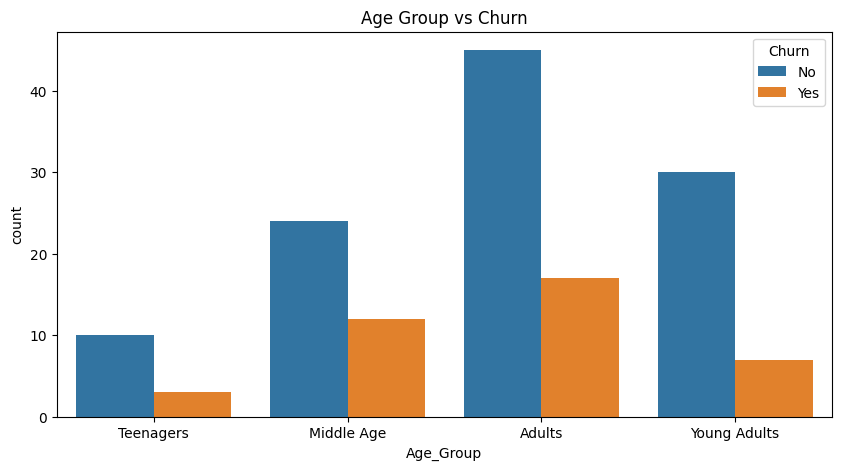

In [1013]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Age_Group',
    hue='Churn',
    data=df
)

plt.title('Age Group vs Churn')
plt.show()

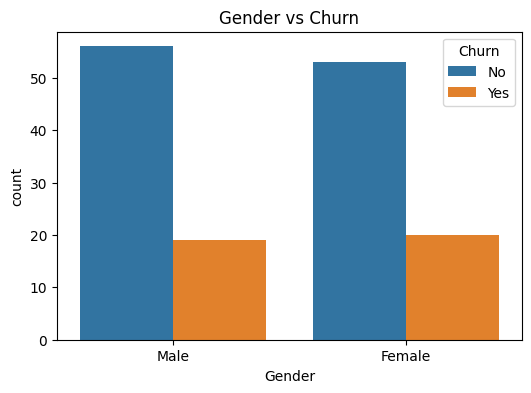

In [1014]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Churn',
    data=df
)

plt.title('Gender vs Churn')
plt.show()

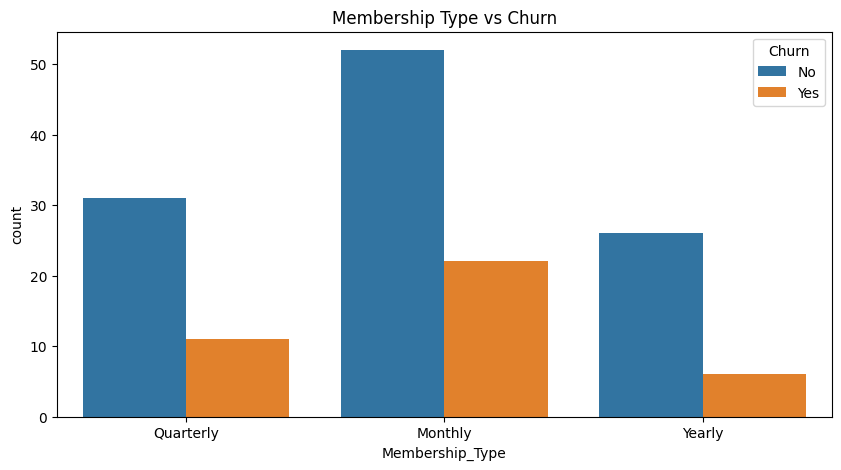

In [1015]:
plt.figure(figsize=(10,5))

sns.countplot(
    x='Membership_Type',
    hue='Churn',
    data=df
)

plt.title('Membership Type vs Churn')
plt.show()

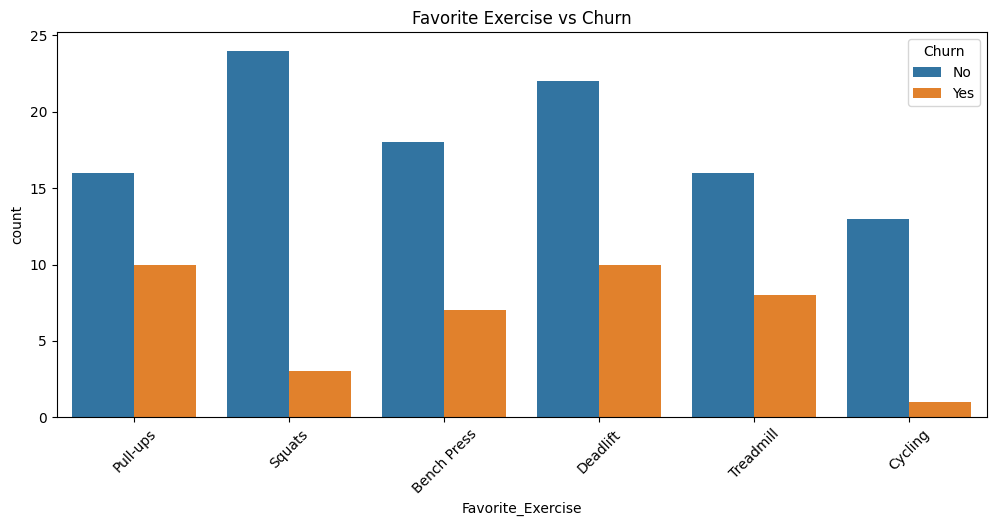

In [1016]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Favorite_Exercise',
    hue='Churn',
    data=df
)

plt.xticks(rotation=45)
plt.title('Favorite Exercise vs Churn')
plt.show()

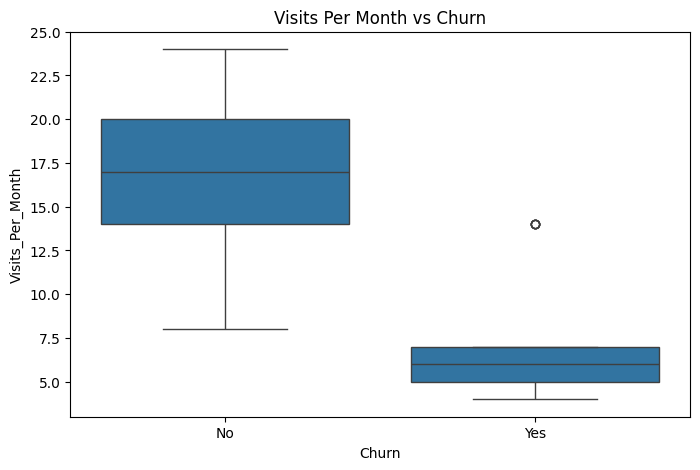

In [1017]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Visits_Per_Month',
    data=df
)

plt.title('Visits Per Month vs Churn')
plt.show()

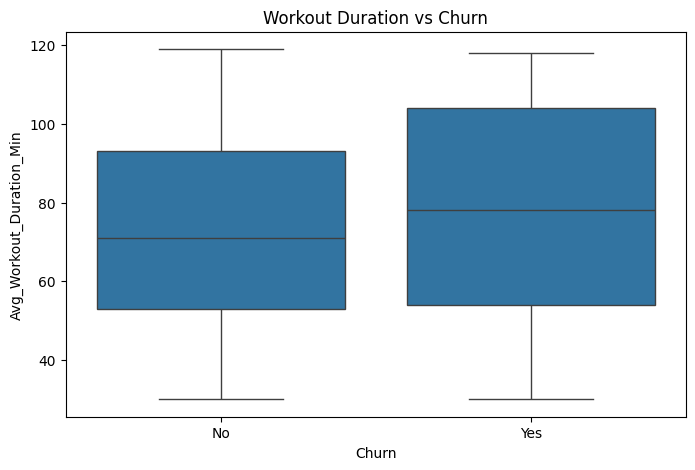

In [1018]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Avg_Workout_Duration_Min',
    data=df
)

plt.title('Workout Duration vs Churn')
plt.show()

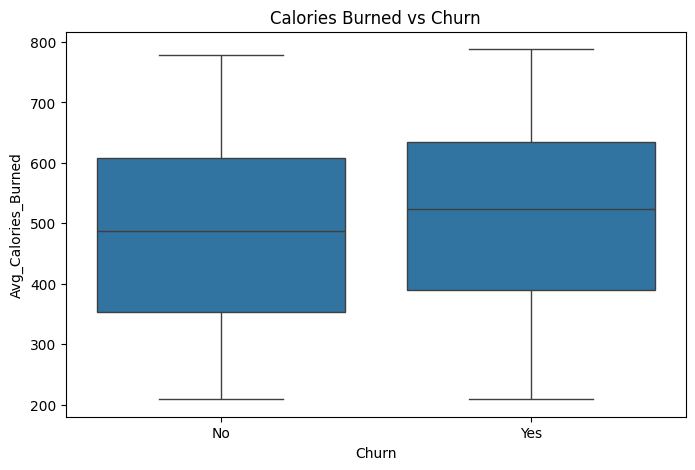

In [1019]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Avg_Calories_Burned',
    data=df
)

plt.title('Calories Burned vs Churn')
plt.show()

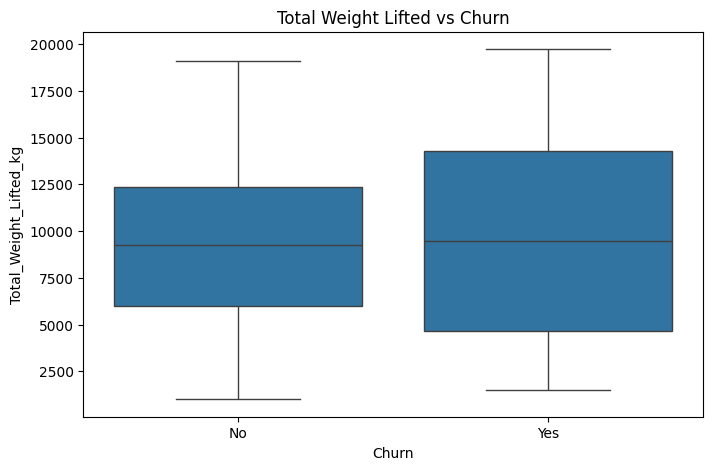

In [1020]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Total_Weight_Lifted_kg',
    data=df
)

plt.title('Total Weight Lifted vs Churn')
plt.show()

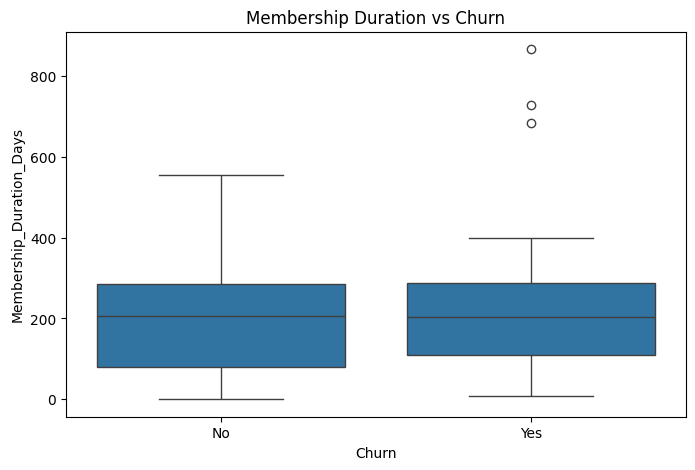

In [1021]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Membership_Duration_Days',
    data=df
)

plt.title('Membership Duration vs Churn')
plt.show()

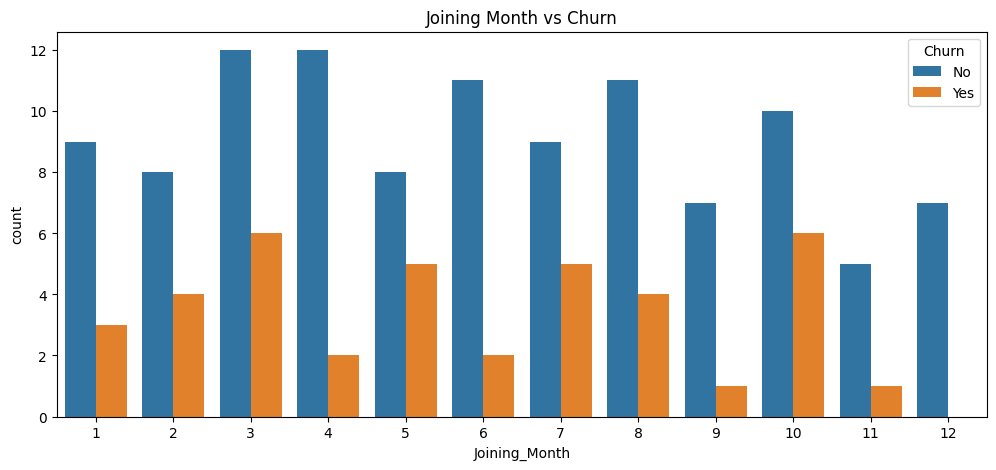

In [1022]:
plt.figure(figsize=(12,5))

sns.countplot(
    x='Joining_Month',
    hue='Churn',
    data=df
)

plt.title('Joining Month vs Churn')
plt.show()

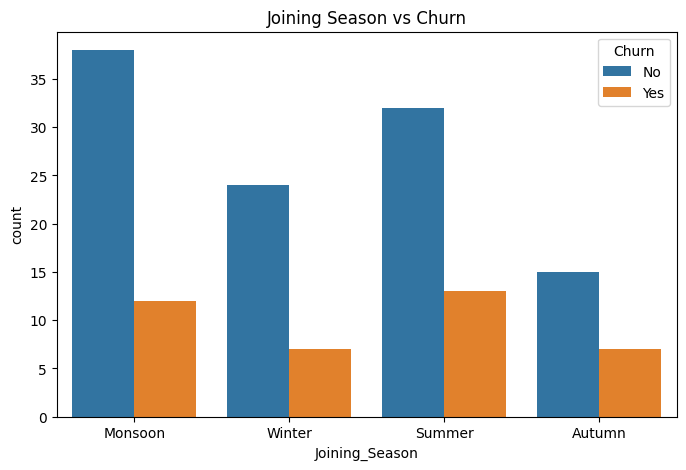

In [1023]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='Joining_Season',
    hue='Churn',
    data=df
)

plt.title('Joining Season vs Churn')
plt.show()

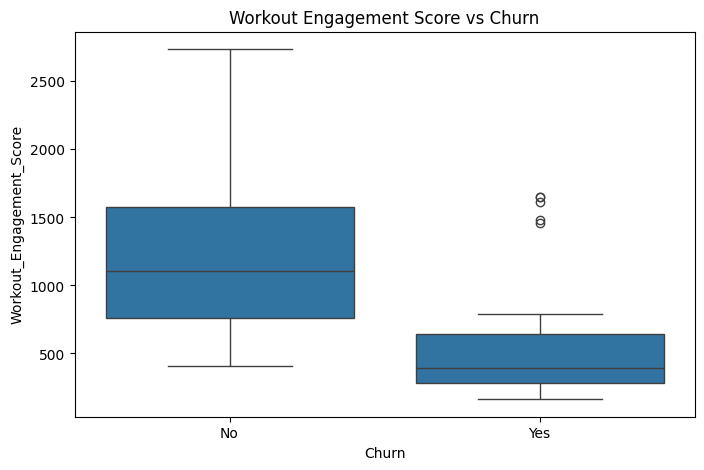

In [1024]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Workout_Engagement_Score',
    data=df
)

plt.title('Workout Engagement Score vs Churn')
plt.show()

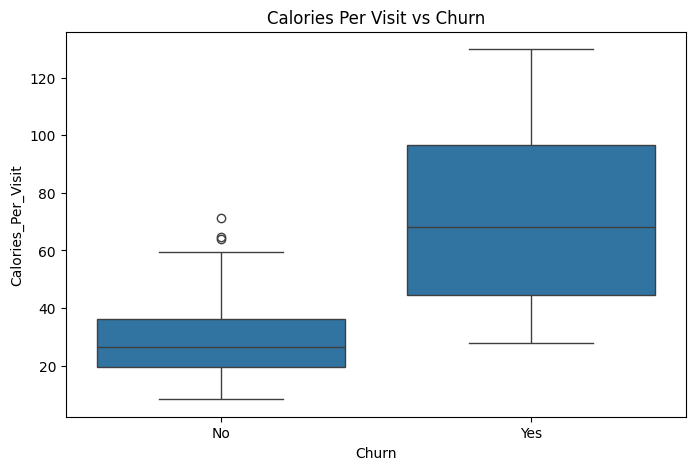

In [1025]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn',
    y='Calories_Per_Visit',
    data=df
)

plt.title('Calories Per Visit vs Churn')
plt.show()

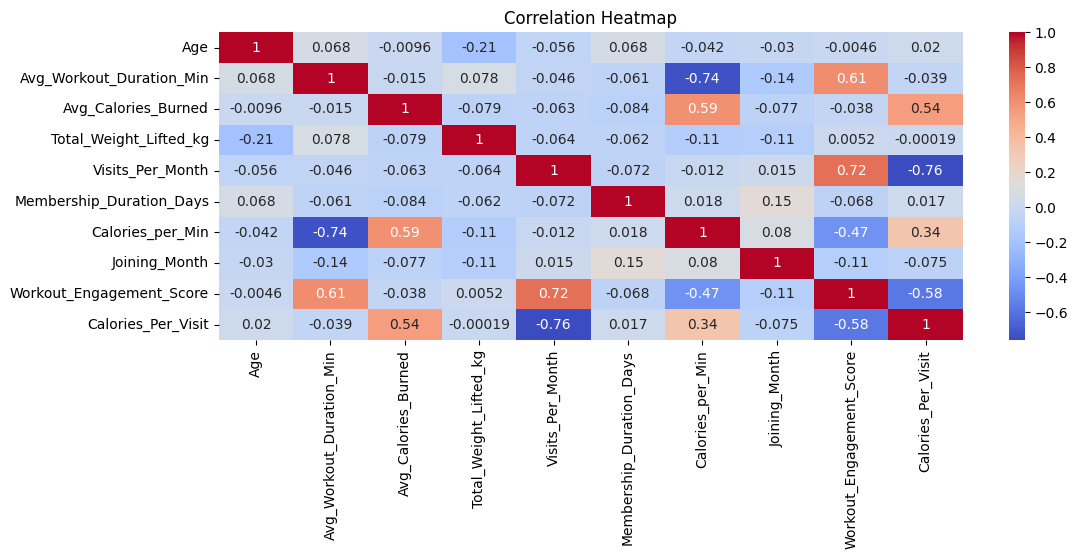

In [1026]:
plt.figure(figsize=(12,4))

corr = df.select_dtypes(include=np.number).corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

**Removing Features Creating Multicolliniarity to improve the model**

In [1027]:
df.drop(columns=['Calories_per_Min', 'Calories_Per_Visit' , 'Joining_Month' , 'Age' , 'Total_Weight_Lifted_kg'], inplace=True)

**Outlier Detection and removal**

In [1028]:
df.shape

(148, 11)

In [1029]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 149
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    148 non-null    object 
 1   Membership_Type           148 non-null    object 
 2   Favorite_Exercise         148 non-null    object 
 3   Avg_Workout_Duration_Min  148 non-null    int64  
 4   Avg_Calories_Burned       148 non-null    float64
 5   Visits_Per_Month          148 non-null    float64
 6   Churn                     148 non-null    object 
 7   Membership_Duration_Days  148 non-null    int64  
 8   Joining_Season            148 non-null    object 
 9   Age_Group                 148 non-null    object 
 10  Workout_Engagement_Score  148 non-null    float64
dtypes: float64(3), int64(2), object(6)
memory usage: 13.9+ KB


In [1030]:
# Select numeric columns

#numeric_cols = df.select_dtypes(include=np.number).columns

#Q1 = df[numeric_cols].quantile(0.25)
#Q3 = df[numeric_cols].quantile(0.75)
#IQR = Q3 - Q1

# Remove outliers

#mask = ~(
    #((df[numeric_cols] < (Q1 - 1.5 * IQR)) |
    #(df[numeric_cols] > (Q3 + 1.5 * IQR))).any(axis=1)
#)

# Filter dataset

#df = df[mask]

#print(df.shape)

In [1031]:
#numeric_cols = df.select_dtypes(include=np.number).columns

#for col in numeric_cols:
#    lower = Q1[col] - 1.5 * IQR[col]
#   upper = Q3[col] + 1.5 * IQR[col]

#    df[col] = np.clip(
#        df[col],
#        lower,
#        upper
#    )

**Preprocessing**

In [1032]:
X = df.drop("Churn",axis=1)
y = df["Churn"]

In [1033]:
y = y.map(
    {"No":0,
    "Yes":1}
)

In [1034]:
y.value_counts()

Churn
0    109
1     39
Name: count, dtype: int64

In [1035]:
X.info()

<class 'pandas.core.frame.DataFrame'>
Index: 148 entries, 0 to 149
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Gender                    148 non-null    object 
 1   Membership_Type           148 non-null    object 
 2   Favorite_Exercise         148 non-null    object 
 3   Avg_Workout_Duration_Min  148 non-null    int64  
 4   Avg_Calories_Burned       148 non-null    float64
 5   Visits_Per_Month          148 non-null    float64
 6   Membership_Duration_Days  148 non-null    int64  
 7   Joining_Season            148 non-null    object 
 8   Age_Group                 148 non-null    object 
 9   Workout_Engagement_Score  148 non-null    float64
dtypes: float64(3), int64(2), object(5)
memory usage: 12.7+ KB


In [1036]:
cat_columns = X.select_dtypes("object").columns
cat_transformer = OneHotEncoder(handle_unknown = 'ignore')

In [1037]:
num_columns = X.select_dtypes("int","float").columns
num_transformer = StandardScaler()

In [1038]:
Preprocessor = ColumnTransformer(

    transformers= [
        ("num",num_transformer,num_columns),
        ("cat",cat_transformer,cat_columns)
    ]
)

In [1039]:
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state = 42,stratify = y,test_size = 0.2)

In [1050]:
smote = SMOTETomek(
    random_state=42
)

In [1041]:
y_train.value_counts()

Churn
0    87
1    31
Name: count, dtype: int64

In [1042]:
X_train_preprocessed = Preprocessor.fit_transform(X_train)
X_test_preprocessed = Preprocessor.fit_transform(X_test)

In [1043]:
X_train_smote,y_train_smote = smote.fit_resample(X_train_preprocessed,y_train)

In [1044]:
y_train_smote.value_counts()

Churn
0    84
1    84
Name: count, dtype: int64

**Model Building + Hyperparameter Tuning**

In [1045]:
models = {

    'Logistic Regression': (
        LogisticRegression(
            max_iter=1000,
            class_weight='balanced'
        ),

        {
            'model__C': [0.1, 1, 10]
        }
    ),

    'Random Forest': (
        RandomForestClassifier(
            random_state=42,
            class_weight='balanced'
        ),

        {
            'model__n_estimators': [100, 200],
            'model__max_depth': [None, 5, 10]
        }
    ),

    'Gradient Boosting': (
        GradientBoostingClassifier(
            random_state=42
        ),

        {
            'model__n_estimators': [100, 150],
            'model__learning_rate': [0.05, 0.1]
        }
    ),

    'SVM': (
        SVC(
            probability=True,
            class_weight='balanced'
        ),

        {
            'model__C': [0.1, 1, 10],
            'model__kernel': ['linear', 'rbf']
        }
    ),

    'XGBoost': (
        XGBClassifier(
            eval_metric='logloss',
            random_state=42,

            # imbalance handling
            scale_pos_weight=(
                y_train.value_counts()[0] /
                y_train.value_counts()[1]
            )
        ),

        {
            'model__n_estimators': [50, 100, 200],

            'model__max_depth': [3, 5, 7],

            'model__learning_rate': [0.01, 0.05, 0.1],

            'model__subsample': [0.8, 1.0]
        }
    )
}

In [1046]:
results = []

for name, (model, params) in models.items():

    pipeline = ImbPipeline([
        ('preprocessor', Preprocessor),

        ('smote', smote),

        ('model', model)
    ])

    grid = GridSearchCV(
        estimator=pipeline,
        param_grid=params,
        cv=3,
        scoring='roc_auc',

        # IMPORTANT FIX
        n_jobs=1,

        verbose=1
    )

    grid.fit(X_train, y_train)

    preds = grid.predict(X_test)
    probs = grid.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test, preds)
    auc = roc_auc_score(y_test, probs)

    print("\n", "="*50)
    print(name)
    print("="*50)

    print("Best Parameters:", grid.best_params_)
    print("Accuracy:", accuracy)
    print("ROC-AUC:", auc)

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'ROC_AUC': auc
    })

Fitting 3 folds for each of 3 candidates, totalling 9 fits

Logistic Regression
Best Parameters: {'model__C': 10}
Accuracy: 0.5333333333333333
ROC-AUC: 0.5
Fitting 3 folds for each of 6 candidates, totalling 18 fits

Random Forest
Best Parameters: {'model__max_depth': None, 'model__n_estimators': 100}
Accuracy: 0.6666666666666666
ROC-AUC: 0.5568181818181819
Fitting 3 folds for each of 4 candidates, totalling 12 fits

Gradient Boosting
Best Parameters: {'model__learning_rate': 0.05, 'model__n_estimators': 150}
Accuracy: 0.6
ROC-AUC: 0.5625
Fitting 3 folds for each of 6 candidates, totalling 18 fits

SVM
Best Parameters: {'model__C': 1, 'model__kernel': 'linear'}
Accuracy: 0.4666666666666667
ROC-AUC: 0.4829545454545454
Fitting 3 folds for each of 54 candidates, totalling 162 fits

XGBoost
Best Parameters: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}
Accuracy: 0.6333333333333333
ROC-AUC: 0.6761363636363636


In [1047]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(by='ROC_AUC', ascending=False)
print(results_df)

                 Model  Accuracy   ROC_AUC
4              XGBoost  0.633333  0.676136
2    Gradient Boosting  0.600000  0.562500
1        Random Forest  0.666667  0.556818
0  Logistic Regression  0.533333  0.500000
3                  SVM  0.466667  0.482955


In [1048]:
best_model_name = results_df.iloc[0]['Model']

print('Best Model:', best_model_name)

Best Model: XGBoost


In [1051]:
final_pipeline = ImbPipeline([
    ('preprocessor', Preprocessor),

    ('smote', smote
    ),

    (
        'model',

        XGBClassifier(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.05,
            subsample=1.0,
            eval_metric='logloss',
            random_state=42
        )
    )
])

final_pipeline.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The

In [1052]:
y_pred = final_pipeline.predict(X_test)

In [1055]:
y_prob = final_pipeline.predict_proba(X_test)[:,1]

In [1056]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy:", accuracy)

print("\nROC-AUC Score:", roc_auc)

print("\nClassification Report:\n")

print(classification_report(y_test, y_pred))

Accuracy: 0.7

ROC-AUC Score: 0.625

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.77      0.79        22
           1       0.44      0.50      0.47         8

    accuracy                           0.70        30
   macro avg       0.63      0.64      0.63        30
weighted avg       0.71      0.70      0.71        30



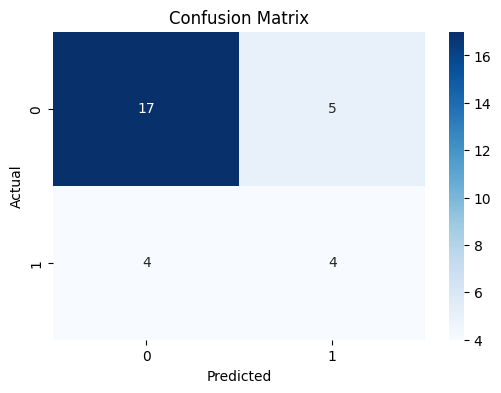

In [1057]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

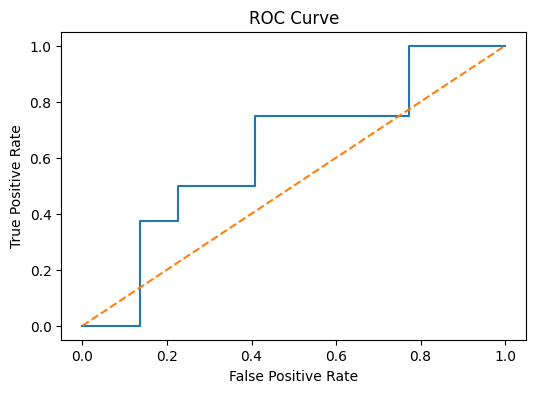

In [1058]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve')

plt.show()

In [1059]:
importance = final_pipeline.named_steps[
    'model'
].feature_importances_

feature_names = final_pipeline.named_steps[
    'preprocessor'
].get_feature_names_out()

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance_df.head(10))

                               Feature  Importance
15          cat__Joining_Season_Summer    0.130988
7   cat__Favorite_Exercise_Bench Press    0.099034
5       cat__Membership_Type_Quarterly    0.073787
10     cat__Favorite_Exercise_Pull-ups    0.067677
4         cat__Membership_Type_Monthly    0.061252
8       cat__Favorite_Exercise_Cycling    0.059449
11       cat__Favorite_Exercise_Squats    0.058371
12    cat__Favorite_Exercise_Treadmill    0.047720
20         cat__Age_Group_Young Adults    0.046842
1        num__Membership_Duration_Days    0.046760


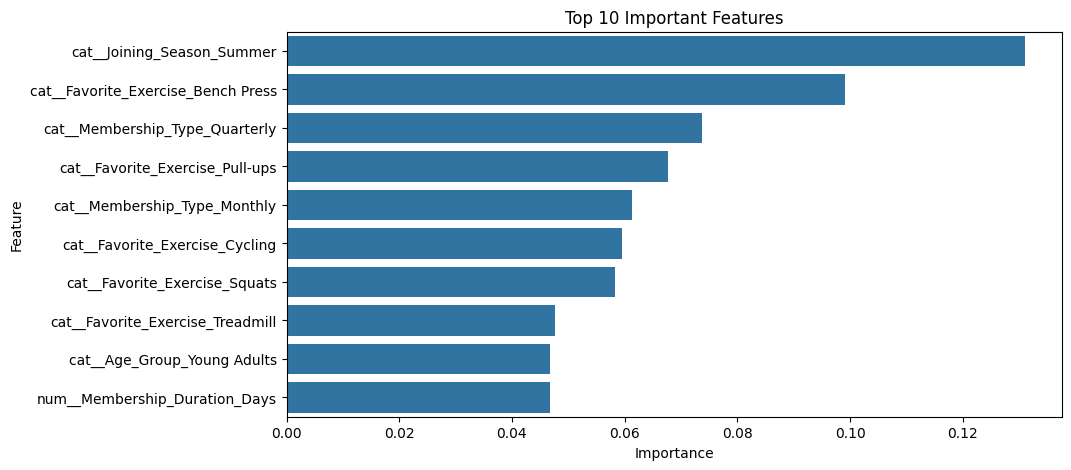

In [1060]:
top_features = feature_importance_df.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 10 Important Features')

plt.show()

In [1063]:
with open('gym_churn_model.pkl', 'wb') as f:

    pickle.dump(final_pipeline, f)

print("Model saved successfully!")

Model saved successfully!
